In [1]:
from google.colab import files
uploaded = files.upload()

Saving flame_detection_file.zip to flame_detection_file.zip


In [2]:
import zipfile

zip_path = "flame_detection_file.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.6 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO


model = YOLO("yolov8n.pt")


model.train(
    data="/content/dataset/Flame/data.yaml",
    epochs=50,
    imgsz=640
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/Flame/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

RuntimeError: Dataset '/content/dataset/Flame/data.yaml' error ❌ '/content/dataset/Flame/data.yaml' does not exist

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

model.predict(
    source="/content/dataset/Flame/test/images",
    conf=0.5,
    save=True
)


image 1/101 /content/dataset/Flame/test/images/125_jpg.rf.f859b47470629e525728120b7f9f9fad.jpg: 384x640 1 Fire, 45.7ms
image 2/101 /content/dataset/Flame/test/images/132_jpg.rf.e27599473b12ca6f2e0d8cfc2946e531.jpg: 384x640 1 Fire, 8.1ms
image 3/101 /content/dataset/Flame/test/images/135_jpg.rf.317d455e19ea5d040c55f639be182812.jpg: 384x640 1 Fire, 6.6ms
image 4/101 /content/dataset/Flame/test/images/141_jpg.rf.9e938d57339c7d04288b847731db3dcd.jpg: 384x640 1 Fire, 5.8ms
image 5/101 /content/dataset/Flame/test/images/153_jpg.rf.f705c1d0f34da3c11632d9d4488110a5.jpg: 384x640 1 Fire, 5.6ms
image 6/101 /content/dataset/Flame/test/images/164_jpg.rf.77073f324759f87ad4d7545ed874b3aa.jpg: 384x640 1 Fire, 5.8ms
image 7/101 /content/dataset/Flame/test/images/169_jpg.rf.0f1ce06e272a33d1ce7d60eeecbde147.jpg: 384x640 1 Fire, 5.7ms
image 8/101 /content/dataset/Flame/test/images/180_jpg.rf.ca65196036f9d5fbe8d676b0d5bab7b6.jpg: 384x640 1 Fire, 5.5ms
image 9/101 /content/dataset/Flame/test/images/186_jpg

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Fire'}
 obb: None
 orig_img: array([[[18, 22, 23],
         [19, 23, 24],
         [21, 25, 26],
         ...,
         [19, 29, 47],
         [19, 29, 47],
         [19, 29, 47]],
 
        [[19, 23, 24],
         [19, 23, 24],
         [21, 25, 26],
         ...,
         [19, 29, 47],
         [19, 29, 47],
         [19, 29, 47]],
 
        [[19, 23, 24],
         [20, 24, 25],
         [20, 24, 25],
         ...,
         [19, 29, 47],
         [19, 29, 47],
         [19, 29, 47]],
 
        ...,
 
        [[15, 15, 69],
         [15, 15, 69],
         [15, 15, 69],
         ...,
         [30, 47, 96],
         [30, 47, 96],
         [30, 47, 96]],
 
        [[16, 16, 70],
         [16, 16, 70],
         [16, 16, 70],
         ...,
         [30, 47, 96],
         [30, 47, 96],
         [30, 47, 96]],
 
        [[17, 17, 71],
      

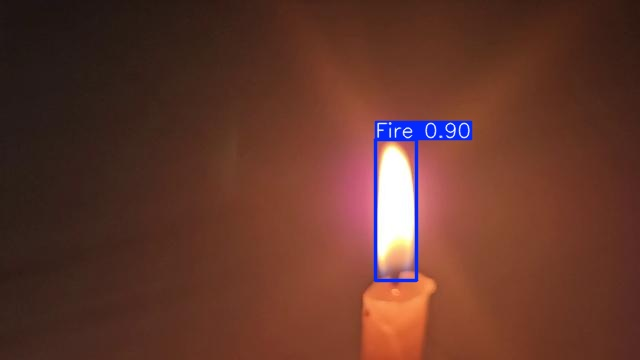

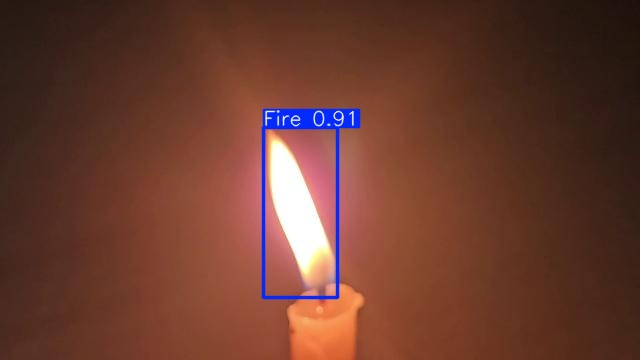

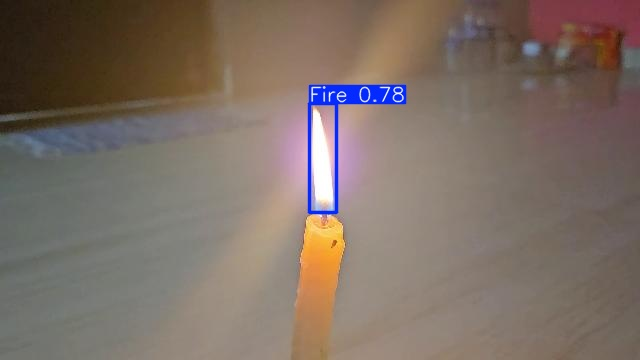

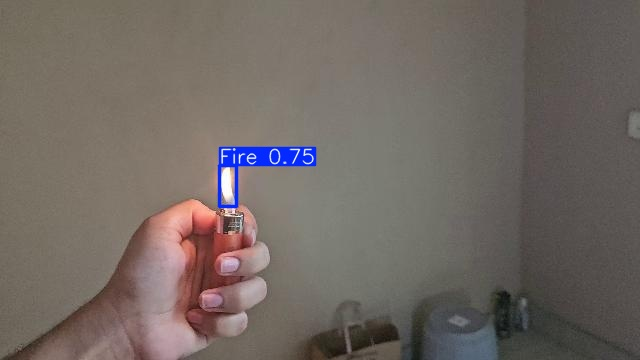

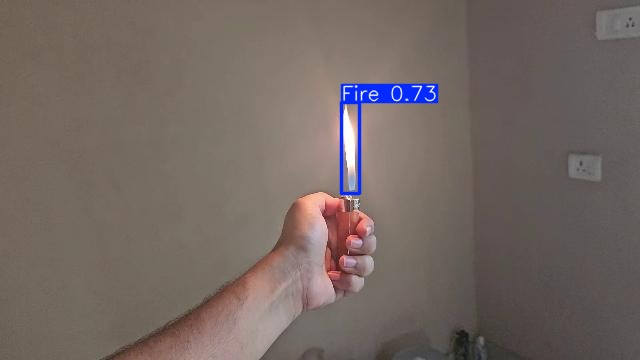

In [ ]:
from IPython.display import Image, display
import os

folder = "/content/runs/detect/predict"

for img in os.listdir(folder)[:5]:  # show 5 images
    display(Image(filename=os.path.join(folder, img)))

In [ ]:
metrics = model.val()

print(f"mAP50 (Accuracy): {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall: {metrics.box.mr:.3f}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 269.5±120.6 MB/s, size: 10.9 KB)
val: Scanning /content/dataset/Flame/valid/labels.cache... 444 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 444/444 206.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 6.2it/s 4.5s
                   all        444        462      0.938      0.948      0.964      0.591
Speed: 1.3ms preprocess, 2.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val2
mAP50 (Accuracy): 0.964
mAP50-95: 0.591
Precision: 0.938
Recall: 0.948


In [ ]:
model.predict(
    source="/content/dataset/Flame/test/images/3_jpg.rf.c2c3fa0136f771f903e91e8f91ec0b7b.jpg",
    conf=0.5,
    show=True
)

NameError: name 'model' is not defined